1. Load everything 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prices = pd.read_csv(
    "../data/processed/clean_prices.csv",
    index_col=0,
    parse_dates=True
).dropna()

strategy = pd.read_csv(
    "../data/processed/strategy_signals.csv",
    index_col=0,
    parse_dates=True
).dropna()

returns = prices.pct_change().fillna(0)

position = strategy["position"]

In [5]:
# Hedge ratio 

import statsmodels.api as sm

log_prices = np.log(prices)

X = sm.add_constant(log_prices["PEP"])
model = sm.OLS(log_prices["KO"], X).fit()

beta = model.params["PEP"]

print(f"Hedge ratio β = {beta:.4f}")

Hedge ratio β = 0.9366


2. Define a dollar-neutral portfolio 

For a long spread: 
+$5,000 KO
-$5,000 PEP

For a short spread: 
-$5,000 KO
+$5,000 PEP

But because beta != 1, we want the hedge ratio reflected in the allocation. 

A simple normalized allocation is: 
w_KO = 1/(1+beta)
w_PEP = beta/(1+beta)

In [6]:
w_ko = 1 / (1 + beta)
w_pep = beta / (1 + beta)

print(f"KO weight:  {w_ko:.4f}")
print(f"PEP weight: {w_pep:.4f}")
print(f"Total:      {w_ko + w_pep:.4f}")

KO weight:  0.5164
PEP weight: 0.4836
Total:      1.0000


3. Calculate gross strategy returns 

In [7]:
spread_returns = (
    w_ko * returns["KO"]
    - w_pep * returns["PEP"]
)

gross_returns = (
    position.shift(1) * spread_returns
).fillna(0)

4. Calculate trading activity 

In [8]:
position_change = position.diff().abs().fillna(0)

position_change.value_counts()

position
0.0    2076
1.0      67
Name: count, dtype: int64

5. Add transaction cost 

In [9]:
# Let's assume

transaction_cost = 0.0005

In [10]:
costs = position_change * transaction_cost

net_returns = gross_returns - costs

6. Add slippage 

In [11]:
slippage = 0.0005

slippage_costs = position_change * slippage

net_returns = (
    gross_returns
    - costs
    - slippage_costs
)

Transaction cost = 5 bps
Slippage         = 5 bps
Total execution friction ≈ 10 bps

7. Compare gross vs net performance

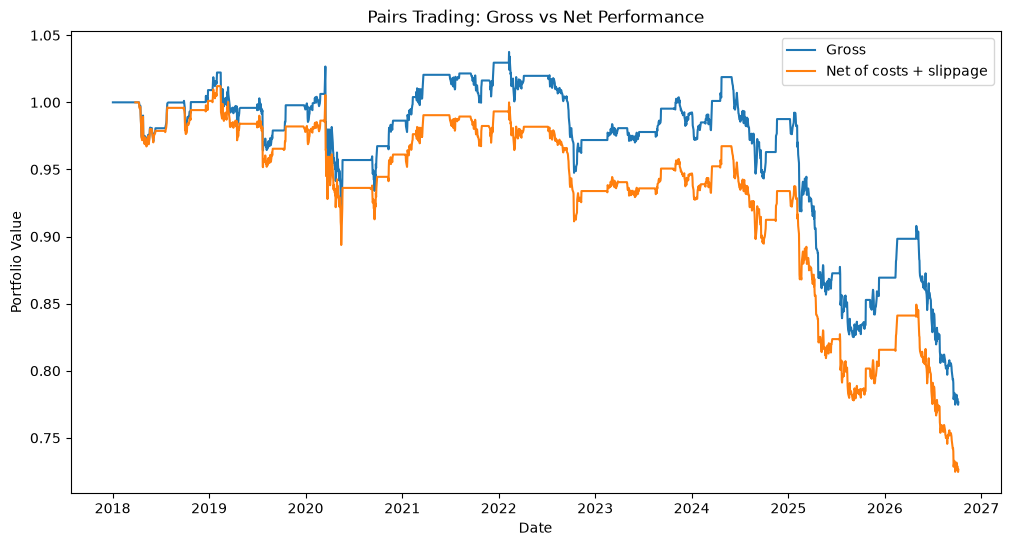

In [12]:
gross_equity = (1 + gross_returns).cumprod()
net_equity = (1 + net_returns).cumprod()

#plot 

plt.figure(figsize=(12, 6))

plt.plot(
    gross_equity,
    label="Gross"
)

plt.plot(
    net_equity,
    label="Net of costs + slippage"
)

plt.title("Pairs Trading: Gross vs Net Performance")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()
plt.show()

8. Create a performance function // so we can reuse it 

In [13]:
def performance_metrics(returns):

    equity = (1 + returns).cumprod()

    total_return = equity.iloc[-1] - 1

    annualized_return = (
        (1 + total_return) ** (252 / len(returns))
        - 1
    )

    volatility = (
        returns.std() * np.sqrt(252)
    )

    sharpe = (
        returns.mean() /
        returns.std()
    ) * np.sqrt(252)

    running_max = equity.cummax()

    drawdown = (
        equity / running_max
    ) - 1

    max_drawdown = drawdown.min()

    return {
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": volatility,
        "Sharpe Ratio": sharpe,
        "Maximum Drawdown": max_drawdown,
    }

In [14]:
# run 

gross_metrics = performance_metrics(gross_returns)
net_metrics = performance_metrics(net_returns)

print("GROSS")
print(gross_metrics)

print("\nNET")
print(net_metrics)

GROSS
{'Total Return': np.float64(-0.22358484084754127), 'Annualized Return': np.float64(-0.028546086108601543), 'Annualized Volatility': np.float64(0.06020340921376204), 'Sharpe Ratio': np.float64(-0.4508903558844187), 'Maximum Drawdown': np.float64(-0.25336848305871895)}

NET
{'Total Return': np.float64(-0.27373836269495455), 'Annualized Return': np.float64(-0.03594169991561469), 'Annualized Volatility': np.float64(0.060573000201007976), 'Sharpe Ratio': np.float64(-0.5905462419497668), 'Maximum Drawdown': np.float64(-0.284016649141432)}


9. Calculate total trading cost 

In [15]:
total_cost = (
    costs + slippage_costs
).sum()

print(
    f"Total execution costs: "
    f"{total_cost:.4f}"
)

Total execution costs: 0.0670


# number of trades 

In [16]:
trade_count = (
    position_change > 0
).sum()

print(f"Number of position changes: {trade_count}")

Number of position changes: 67


10. Save the realistic backtest 

In [17]:
backtest = pd.DataFrame({
    "position": position,
    "gross_return": gross_returns,
    "transaction_cost": costs,
    "slippage": slippage_costs,
    "net_return": net_returns,
    "gross_equity": gross_equity,
    "net_equity": net_equity,
})

backtest.to_csv(
    "data/processed/backtest.csv"
)

print("Saved realistic backtest.")

Saved realistic backtest.


Next, we will conduct trade-level analysis and robustness. We'll examine individual trades, holding periods, profit/loss distribution, and then test whether the strategy still works when we change the Z-score thresholds and rolling window. That's where we start addressing overfitting.